In [18]:
%load_ext autoreload
%autoreload 2
import collections, pandas as pd, matplotlib, matplotlib.pyplot as plt, seaborn as sns
from af2genomics import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
df_models = read_ppi_reselect().query('pdockq > .5')#.query('afparams != "fd_rev"')#.query('interface_plddt > 90')
df_models

310,581 raw records from /cluster/work/beltrao/jjaenes/23.12.06_ppi_reselect/interface_strict_best2_p10.csv
310,572 after discarding non-dimers
210,772 after keeping uniprot_id-s in AF2 single fragment structures
210,770 after naive de-duplication of interaction_id
106,116 with pdockq > .23
24,524 with pdockq > .5


,interaction_id,pair,afparams,interface_plddt,pdockq,pdockq_fd,pdockq2,clashes,protein1,chain1,residues1,protein2,chain2,residues2,pair1,pair2,pdb
82,O75506_Q8WUW1,O75506_Q8WUW1,multimer1,94.0,0.58,0.476,0.76,0,O75506,A,"16,17,20,23,24,27,28,30,31,32,34,35,38,41,42,4...",Q8WUW1,B,"21,24,25,28,31,32,35,36,39,42,43,46,47,50,53,5...",O75506,Q8WUW1,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
84,O75506_O75506,O75506_O75506,fd,90.0,0.52,0.458,NaN,0,O75506,A,"4,8,12,15,16,19,20,22,23,26,27,30,33,34,37,38,...",O75506,B,"4,9,12,13,16,17,20,23,24,27,28,31,32,34,35,38,...",O75506,O75506,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
129,A8MWD9_P62306,A8MWD9_P62306,af1_fd,91.0,0.56,0.476,0.77,0,A8MWD9,A,"14,21,22,25,32,33,34,35,37,39,40,41,43,47,56,5...",P62306,B,"1,2,3,4,5,6,7,8,10,11,22,24,38,39,40,42,66,67,...",A8MWD9,P62306,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
163,P62308_Q9Y4Y9,P62308_Q9Y4Y9,multimer1,96.0,0.60,0.524,0.91,0,P62308,A,"10,13,21,22,23,25,27,32,33,34,35,37,39,40,41,4...",Q9Y4Y9,B,"10,11,12,13,14,15,17,18,29,30,31,32,33,34,45,4...",P62308,Q9Y4Y9,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
164,A8MWD9_P62304,A8MWD9_P62304,multimer1,95.0,0.63,0.556,0.90,0,A8MWD9,A,"10,13,14,21,22,23,25,27,32,33,34,35,37,39,40,4...",P62304,B,"12,13,14,15,16,17,18,20,21,24,34,35,36,37,39,4...",A8MWD9,P62304,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210721,O15294_Q9BTC0,O15294_Q9BTC0,multimer1,72.0,0.62,0.402,0.00,0,O15294,A,"5,7,8,9,12,13,14,15,16,18,19,36,38,39,40,42,68...",Q9BTC0,B,"2024,2026,2027,2028,2029,2030,2031,2032,2033,2...",O15294,Q9BTC0,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
210738,P61964_Q8NFC6,P61964_Q8NFC6,multimer1,66.0,0.51,0.518,0.00,0,P61964,A,"17,18,19,20,21,22,23,41,44,45,46,47,48,52,53,5...",Q8NFC6,B,"469,470,471,472,473,474,475,477,829,851,856,85...",P61964,Q8NFC6,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
210742,P11142_Q9UQ35,P11142_Q9UQ35,multimer1,70.0,0.59,0.576,0.00,0,P11142,A,"11,12,13,14,15,16,38,39,40,41,42,43,44,45,46,4...",Q9UQ35,B,"603,606,612,1416,1421,1422,1423,1424,1425,1426...",P11142,Q9UQ35,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
210743,Q96BP3_Q9UQ35,Q96BP3_Q9UQ35,multimer1,68.0,0.60,0.600,0.00,0,Q96BP3,A,"34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,4...",Q9UQ35,B,"539,542,543,544,545,546,547,548,549,550,551,55...",Q96BP3,Q9UQ35,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...


In [20]:
# One entry per "interaction matrix" (dimer models = both; homomer models = 1)
cols_ = ['bait_id', 'bait_ifresid', 'bait_chain', 'interactor_id', 'interaction_id', 'pdockq', 'pdb']
q_ne_ = 'protein1 != protein2'
q_eq_ = 'protein1 == protein2'
df_interactors = pd.concat([
    df_models.query(q_ne_).rename({'protein1': 'bait_id', 'residues1': 'bait_ifresid', 'chain1': 'bait_chain', 'protein2': 'interactor_id'}, axis=1)[cols_],
    df_models.query(q_eq_).rename({'protein1': 'bait_id', 'residues1': 'bait_ifresid', 'chain1': 'bait_chain', 'protein2': 'interactor_id'}, axis=1)[cols_],
    df_models.query(q_ne_).rename({'protein2': 'bait_id', 'residues2': 'bait_ifresid', 'chain2': 'bait_chain', 'protein1': 'interactor_id'}, axis=1)[cols_],
], axis=0)
df_interactors

,bait_id,bait_ifresid,bait_chain,interactor_id,interaction_id,pdockq,pdb
82,O75506,"16,17,20,23,24,27,28,30,31,32,34,35,38,41,42,4...",A,Q8WUW1,O75506_Q8WUW1,0.58,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
129,A8MWD9,"14,21,22,25,32,33,34,35,37,39,40,41,43,47,56,5...",A,P62306,A8MWD9_P62306,0.56,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
163,P62308,"10,13,21,22,23,25,27,32,33,34,35,37,39,40,41,4...",A,Q9Y4Y9,P62308_Q9Y4Y9,0.60,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
164,A8MWD9,"10,13,14,21,22,23,25,27,32,33,34,35,37,39,40,4...",A,P62304,A8MWD9_P62304,0.63,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
172,P62304,"12,13,14,15,16,17,18,20,21,23,24,34,35,36,39,4...",A,P62308,P62304_P62308,0.64,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
...,...,...,...,...,...,...,...
210721,Q9BTC0,"2024,2026,2027,2028,2029,2030,2031,2032,2033,2...",B,O15294,O15294_Q9BTC0,0.62,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
210738,Q8NFC6,"469,470,471,472,473,474,475,477,829,851,856,85...",B,P61964,P61964_Q8NFC6,0.51,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
210742,Q9UQ35,"603,606,612,1416,1421,1422,1423,1424,1425,1426...",B,P11142,P11142_Q9UQ35,0.59,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
210743,Q9UQ35,"539,542,543,544,545,546,547,548,549,550,551,55...",B,Q96BP3,Q96BP3_Q9UQ35,0.60,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...


In [21]:
# df_interfaces: summary of interactions per "bait" protein
df_interfaces = df_interactors.groupby('bait_id').agg(
    interactor_id = ('interactor_id', lambda interactor_id: ','.join(sorted(interactor_id))),
    n_interactors = ('interactor_id', lambda x: len(x)),
    resid_counts = ('bait_ifresid', lambda x: collections.Counter(xii for xi in x for xii in parse_resid(xi)))
).reset_index().sort_values('n_interactors', ascending=False)
printlen(df_interfaces)
df_nresid_ = read_structures().query('frag_id == "F1"')[['uniprot_id', 'n_resid']]
df_interfaces = df_interfaces.merge(df_nresid_, left_on='bait_id', right_on='uniprot_id').drop('uniprot_id', axis=1)
printlen(df_interfaces)
df_interfaces = df_interfaces.sort_values('n_interactors', ascending=False).query('n_interactors >= 5')#.sample(n=100, random_state=RANDOM_SEED)
printlen(df_interfaces)
df_interfaces

10,450
10,450
3,164


,bait_id,interactor_id,n_interactors,resid_counts,n_resid
0,P63000,"A1IGU5,A6NI28,A7KAX9,B9A064,O00499,O00629,O145...",90,"{1: 15, 2: 4, 3: 13, 4: 9, 5: 27, 23: 13, 24: ...",192
1,P60709,"A6NGB9,A8K0Z3,O00159,O15144,O15160,O43237,O435...",89,"{143: 58, 16: 17, 144: 40, 145: 41, 146: 52, 1...",375
2,P11142,"A0AVF1,A6NED2,A6NHZ5,O43143,O75937,O75953,O948...",87,"{419: 15, 388: 8, 325: 4, 389: 13, 390: 14, 39...",646
3,P62136,"A8MZ97,B7ZBB8,O14802,O14974,O14990,O15294,O432...",85,"{257: 62, 259: 8, 260: 19, 261: 63, 262: 7, 28...",330
4,P60953,"A1IGU5,A7KAX9,O14613,O15013,O15068,O43182,O432...",85,"{3: 36, 4: 7, 5: 31, 21: 21, 23: 24, 24: 34, 2...",191
...,...,...,...,...,...
2723,Q8WVK7,"Q12834,Q7L2Z9,Q86SE5,Q8IX90,Q96BD8",5,"{12: 3, 16: 2, 17: 3, 19: 3, 20: 3, 22: 4, 23:...",121
2720,P49770,"O60704,P21579,Q13144,Q14232,Q9UI10",5,"{256: 2, 260: 2, 286: 3, 288: 3, 294: 2, 295: ...",351
2722,O60760,"O60760,P09211,P11509,Q96SQ9,Q9H4Y5",5,"{130: 3, 134: 3, 47: 3, 48: 4, 59: 3, 60: 2, 6...",199
2718,Q9UH90,"P60709,P62736,P63208,Q562R1,Q96FJ2",5,"{385: 1, 387: 1, 390: 1, 391: 1, 401: 1, 405: ...",709


P62304 bait uniprot id
20 interaction models sharing the bait
92 number of bait residues
(20, 92) shape matrix dimensions
4278 non-zero entries in residue matrix
2    11
1     8
3     1
Name: labels, dtype: int64


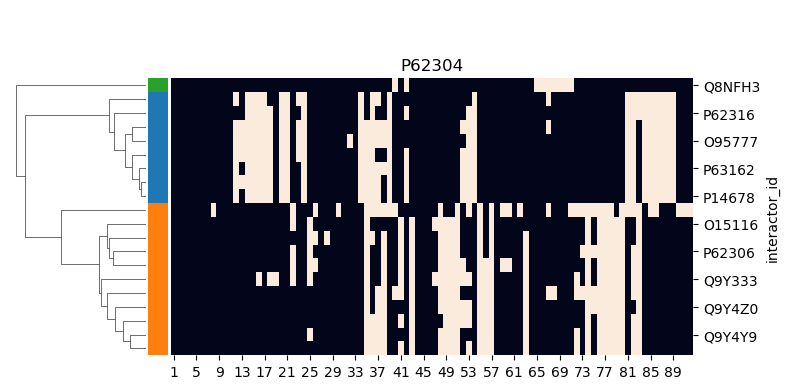

In [22]:
# Cluster single example
l_examples = [
    'P11021', # HSPA5, fig2
    'P31146', # CORO1A, fig5
    'P11362', # FGFR1, fig5
]
for uniprot_id in l_examples:
    bait_ = SharedInterfaceAnalysis(df_interactors.query('bait_id == @uniprot_id'))
    bait_.build_matrix()
    bait_.linkage(t=.9)
    bait_.clustermap(f'interface_clusters_{uniprot_id}.svg')
    bait_.to_pymol(f'interface_clusters_{uniprot_id}.pse')

In [23]:
# Cluster subset, plot distribution
def nclusters_(i, r):
    uniprot_id_bait = r.bait_id
    #pse_ = workpath(f'24.01.22_interface_clusters/{uniprot_id_bait}.pse')
    #svg_ = workpath(f'24.01.22_interface_clusters/{uniprot_id_bait}.svg')
    pse_ = f'interface_clusters/{uniprot_id_bait}.pse'
    svg_ = f'interface_clusters/{uniprot_id_bait}.svg'
    bait_ = SharedInterfaceAnalysis(df_interactors.query('bait_id == @uniprot_id_bait'))
    bait_.build_matrix()
    bait_.linkage()
    #bait_.clustermap(fname=svg_)
    #bait_.to_pymol(fname=pse_)
    return len(bait_.df_interactors['labels'].value_counts())

df_interfaces['nclusters'] = [ nclusters_(i, r) for i, r in df_interfaces.iterrows() ]

P63000 bait uniprot id
90 interaction models sharing the bait
192 number of bait residues
(90, 192) shape matrix dimensions
18528 non-zero entries in residue matrix
1    88
2     1
3     1
Name: labels, dtype: int64
P60709 bait uniprot id
89 interaction models sharing the bait
375 number of bait residues
(89, 375) shape matrix dimensions
70500 non-zero entries in residue matrix
5    67
7     9
1     3
6     3
2     3
3     2
4     1
8     1
Name: labels, dtype: int64
P11142 bait uniprot id
87 interaction models sharing the bait
646 number of bait residues
(87, 646) shape matrix dimensions
208981 non-zero entries in residue matrix
4    46
8    13
9    12
2     8
3     3
1     2
6     1
5     1
7     1
Name: labels, dtype: int64
P62136 bait uniprot id
85 interaction models sharing the bait
330 number of bait residues
(85, 330) shape matrix dimensions
54615 non-zero entries in residue matrix
3    79
1     3
2     3
Name: labels, dtype: int64
P60953 bait uniprot id
85 interaction models sh

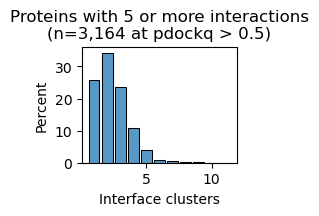

In [24]:
plt.figure(figsize=(2, 1.5))
sns.histplot(data=df_interfaces, x='nclusters', discrete=True, stat='percent', shrink=.8)
plt.title(f'Proteins with 5 or more interactions\n(n={uf(len(df_interfaces))} at pdockq > 0.5)')
plt.gca().set_xlabel('Interface clusters')
plt.savefig('interface_clusters.svg', bbox_inches='tight', transparent=True)